In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Read new Abaqus CSV files
tau = pd.read_csv("sigma_tau_points.csv")
sigma_n = pd.read_csv("sigma_n_points.csv")

print("Raw tau points:", len(tau))
print("Raw sigma_n points:", len(sigma_n))

display(tau.head())
display(sigma_n.head())

Raw tau points: 830
Raw sigma_n points: 309


,N,Node,X,Y,Z,Sigma_tau_MPa
0,0.457758,9376,0.329166,-1.050132,61.572197,813.423706
1,0.424124,9378,0.138017,-0.374702,61.530155,805.211914
2,0.424124,9378,0.138017,-0.374702,61.530155,805.779297
3,3.181128,9782,0.667229,0.235365,64.976410,431.119476
4,3.181128,9782,0.667229,0.235365,64.976410,433.042145


,N,Node,X,Y,Z,Sigma_n_MPa
0,1.978006,3575,0.190571,-3.208633,63.472507,515.316772
1,2.498694,3576,0.348331,3.186917,64.123370,507.750244
2,2.493201,3577,-0.013221,3.221990,64.116500,470.422668
3,5.219214,9339,-3.197158,-0.378608,67.524020,116.762344
4,0.384293,9344,-2.077709,2.469412,61.480366,193.017471


In [16]:
# Round N to 0.1 increments
tau["N_sample"] = (tau["N"] * 10).round() / 10
sigma_n["N_sample"] = (sigma_n["N"] * 10).round() / 10

# Average the FE values belonging to each sampling location
tau_plot = (
    tau.groupby("N_sample", as_index=False)["Sigma_tau_MPa"]
       .mean()
)

sigma_n_plot = (
    sigma_n.groupby("N_sample", as_index=False)["Sigma_n_MPa"]
       .mean()
)

print("Processed tau points:", len(tau_plot))
print("Processed sigma_n points:", len(sigma_n_plot))

Processed tau points: 73
Processed sigma_n points: 69


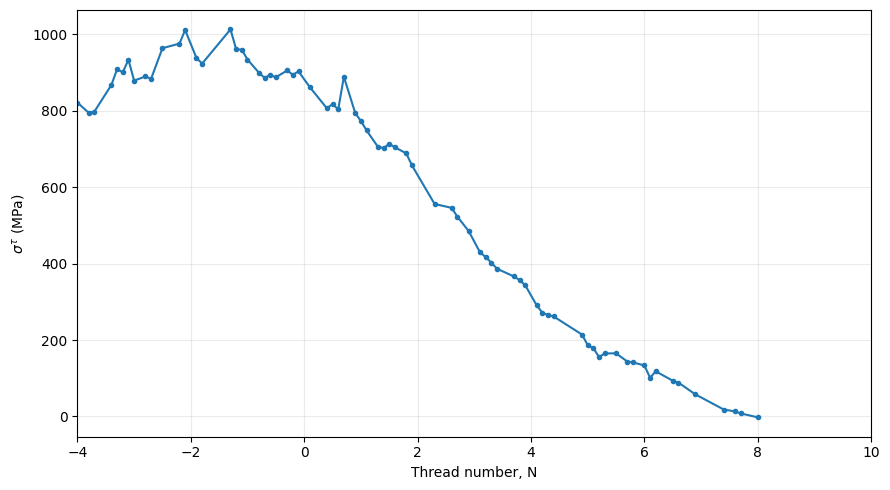

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(
    tau_plot["N_sample"],
    tau_plot["Sigma_tau_MPa"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.xlabel("Thread number, N")
plt.ylabel(r"$\sigma^\tau$ (MPa)")

plt.xlim(-4, 10)

plt.grid(True, alpha=0.25)

plt.tight_layout()

plt.savefig(
    "Fig4_d_sigma_tau.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

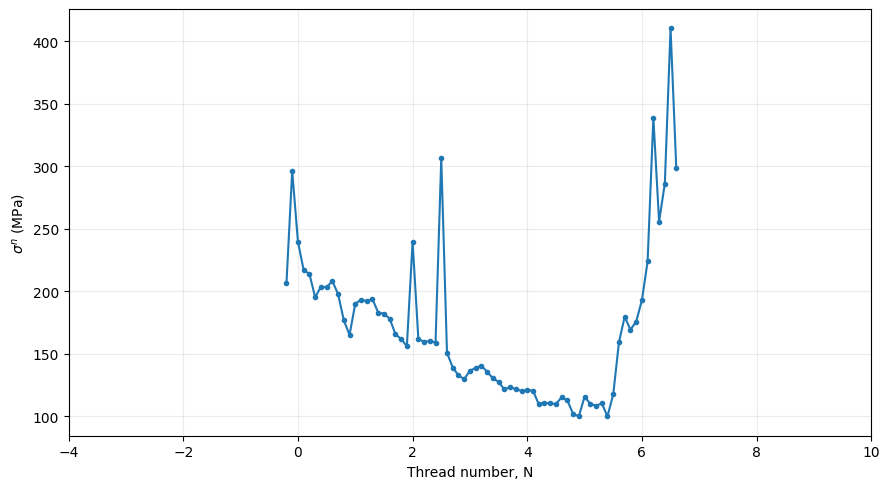

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    sigma_n_plot["N_sample"],
    sigma_n_plot["Sigma_n_MPa"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.xlabel("Thread number, N")
plt.ylabel(r"$\sigma^n$ (MPa)")

plt.xlim(-4, 10)

plt.grid(True, alpha=0.25)

plt.tight_layout()

plt.savefig(
    "Fig4_e_sigma_n.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()